# Практическое занятие №3

## Свёртка и корреляционный анализ сигналов

## Цели занятия
- Освоить вычисление свёртки и корреляции в Python.
- Применить свёртку для фильтрации сигналов.
- Использовать кросс-корреляцию для поиска временной задержки и обнаружения шаблона.
- Проанализировать влияние уровня шума на точность оценок.

## Подготовка окружения

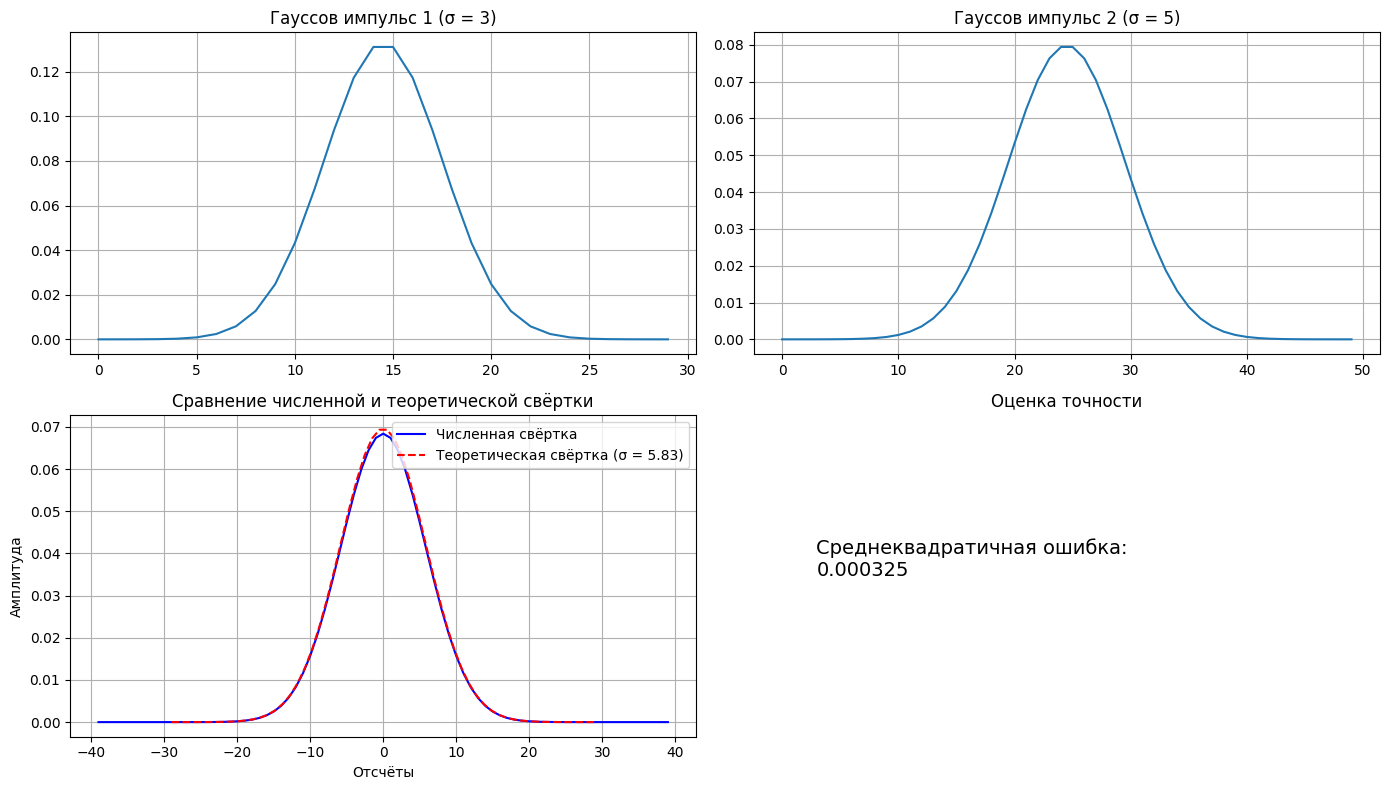

Теоретическая сигма: 5.83
СКО: 0.000325


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Параметры
sigma1 = 3
sigma2 = 5
length1 = int(10 * sigma1)
length2 = int(10 * sigma2)

# Создаём гауссовы окна
gauss1 = signal.windows.gaussian(length1, sigma1)
gauss2 = signal.windows.gaussian(length2, sigma2)

# Нормализуем, чтобы площадь была 1 (как у плотности вероятности)
gauss1 = gauss1 / np.sum(gauss1)
gauss2 = gauss2 / np.sum(gauss2)

# Свёртка
conv_result = np.convolve(gauss1, gauss2, mode='full')

# Теоретический результат
sigma_theor = np.sqrt(sigma1**2 + sigma2**2)
length_theor = int(10 * sigma_theor)
t_theor = np.linspace(-length_theor//2, length_theor//2, length_theor)
gauss_theor = (1 / (np.sqrt(2 * np.pi) * sigma_theor)) * np.exp(-t_theor**2 / (2 * sigma_theor**2))
gauss_theor = gauss_theor / np.sum(gauss_theor)  # нормализация

# Оси для свёртки
t_conv = np.arange(len(conv_result)) - (len(conv_result) // 2)

# Построение графиков
plt.figure(figsize=(14, 8))

plt.subplot(2, 2, 1)
plt.plot(gauss1)
plt.title(f'Гауссов импульс 1 (σ = {sigma1})')
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(gauss2)
plt.title(f'Гауссов импульс 2 (σ = {sigma2})')
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(t_conv, conv_result, 'b-', label='Численная свёртка')
plt.plot(t_theor, gauss_theor, 'r--', label=f'Теоретическая свёртка (σ = {sigma_theor:.2f})')
plt.title('Сравнение численной и теоретической свёртки')
plt.xlabel('Отсчёты')
plt.ylabel('Амплитуда')
plt.legend()
plt.grid(True)

# Ошибка
error = np.std(conv_result - np.interp(t_conv, t_theor, gauss_theor, left=0, right=0))
plt.subplot(2, 2, 4)
plt.text(0.1, 0.5, f'Среднеквадратичная ошибка:\n{error:.6f}', fontsize=14)
plt.axis('off')
plt.title('Оценка точности')

plt.tight_layout()
plt.show()

print(f"Теоретическая сигма: {sigma_theor:.2f}")
print(f"СКО: {error:.6f}")

## Задание 1. Свёртка гауссовых функций: сравнение численного и аналитического результатов

### Теоретическое введение
Свёртка двух гауссовых функций даёт гауссову функцию с дисперсией, равной сумме дисперсий. Если
$$
f(t) = \frac{1}{\sqrt{2\pi\sigma_1^2}} e^{-t^2/(2\sigma_1^2)}, \quad g(t) = \frac{1}{\sqrt{2\pi\sigma_2^2}} e^{-t^2/(2\sigma_2^2)},
$$
то
$$
(f * g)(t) = \frac{1}{\sqrt{2\pi(\sigma_1^2+\sigma_2^2)}} e^{-t^2/(2(\sigma_1^2+\sigma_2^2))}.
$$

### Задание
1. Сгенерируйте дискретные гауссовы импульсы (например, с помощью `scipy.signal.windows.gaussian`) с заданными стандартными отклонениями `sigma1=3`, `sigma2=5`. Используйте длину окна, достаточную для захвата всей значимой части (например, 10*sigma).
2. Вычислите свёртку численно с помощью `np.convolve`.
3. Постройте графики:
   - Исходные функции.
   - Результат свёртки (численный).
   - Теоретическую гауссову функцию с дисперсией `sigma1^2 + sigma2^2`.
4. Оцените среднеквадратичную ошибку между численным и теоретическим результатами.

SyntaxError: invalid syntax (1030850640.py, line 1)

**Вопросы:**
- Что произойдёт с формой свёртки при увеличении σ?

При увеличении q свёртка становится более широкой и имеет меньшую максимальную амплитуду. Это = свойству: дисперсия суммы равна сумме дисперсий, поэтому q увеличивается, а высота уменьшается обратно пропорционально q.

## Задание 2. Фильтрация с помощью свёртки: сравнение прямоугольного и гауссовского окон

### Цель
Изучить, как выбор ядра и его длина влияют на подавление высокочастотной составляющей и сохранение низкочастотной.

### Задание
1. Создайте сигнал длительностью 2 секунды, частота дискретизации 1000 Гц, состоящий из суммы двух синусоид:
   - низкая частота \( f_1 = 5 \) Гц, амплитуда 1,
   - высокая частота \( f_2 = 80 \) Гц, амплитуда 0.5.
2. Сгенерируйте прямоугольное окно длины `L` (например, `L = 21`, используйте `scipy.signal.windows.boxcar(L)`), нормализованное так, чтобы сумма коэффициентов была 1.
3. Сгенерируйте гауссовское окно той же длины (используйте `signal.windows.gaussian(L, std=L/5)`), также нормализованное.
4. Примените свёртку с этими окнами (используйте `mode='same'`).
5. Постройте графики:
   - Исходный сигнал (первые 0.5 с).
   - Отфильтрованные сигналы для обоих окон.
6. Вычислите и сравните амплитуды полезной составляющей (5 Гц) и подавленной (80 Гц) после фильтрации. Для этого:
   - Возьмите БПФ сигналов,
   - Измерьте амплитуды на соответствующих частотах.
7. Исследуйте влияние длины окна: повторите для длин `L = 11, 21, 41, 81`.

Анализ фильтрации для разных длин окон:
------------------------------------------------------------
L     Окно         5 Гц (сохр.)    80 Гц (подавл.)
------------------------------------------------------------
11    Прямоуг.       99.5%           13.6%
11    Гаусс.         99.8%           56.1%
------------------------------------------------------------
21    Прямоуг.       98.2%           16.0%
21    Гаусс.         99.2%           10.0%
------------------------------------------------------------
41    Прямоуг.       93.3%            7.3%
41    Гаусс.         97.0%            0.1%
------------------------------------------------------------
81    Прямоуг.       75.4%            5.1%
81    Гаусс.         88.9%            0.6%
------------------------------------------------------------


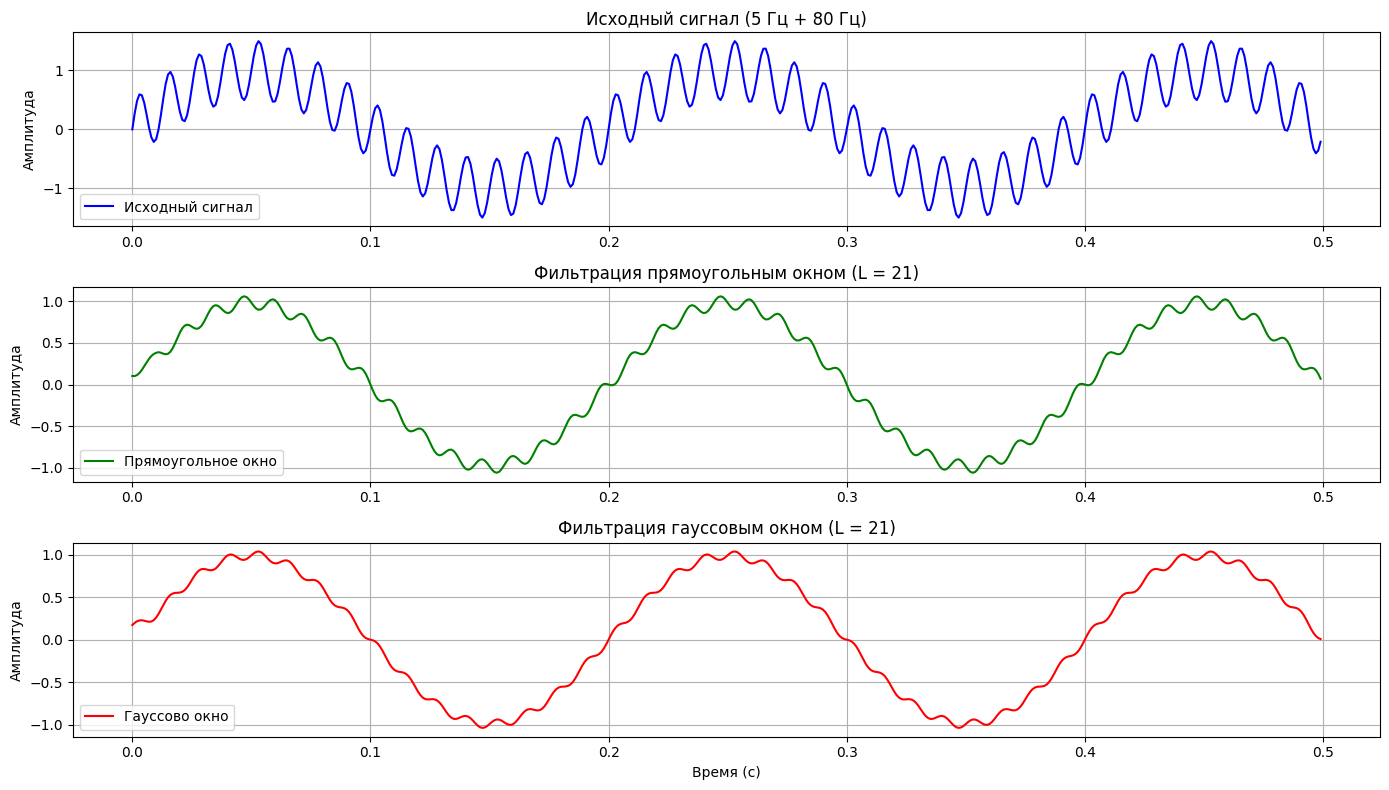

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Параметры
fs = 1000
T = 2
t = np.linspace(0, T, int(fs*T), endpoint=False)

# Сигнал: сумма двух синусоид
f1 = 5
f2 = 80
x = np.sin(2*np.pi*f1*t) + 0.5 * np.sin(2*np.pi*f2*t)

# Исследуемые длины окон
L_values = [11, 21, 41, 81]

# Функция для анализа
def analyze_filter(L, window_type='boxcar'):
    if window_type == 'boxcar':
        h = signal.windows.boxcar(L)
    else:
        h = signal.windows.gaussian(L, std=L/5)
    h = h / np.sum(h)  # нормализация

    y = np.convolve(x, h, mode='same')

    # Спектральный анализ
    N = len(y)
    Xf = np.fft.fft(x)
    Yf = np.fft.fft(y)
    freq = np.fft.fftfreq(N, 1/fs)
    half = N // 2
    freq_pos = freq[:half]

    # Поиск амплитуд на частотах f1 и f2
    idx1 = np.argmin(np.abs(freq_pos - f1))
    idx2 = np.argmin(np.abs(freq_pos - f2))
    amp1_orig = np.abs(Xf[idx1]) / half * 2
    amp2_orig = np.abs(Xf[idx2]) / half * 2
    amp1_filt = np.abs(Yf[idx1]) / half * 2
    amp2_filt = np.abs(Yf[idx2]) / half * 2

    return amp1_filt / amp1_orig, amp2_filt / amp2_orig

# Сравнение окон
print("Анализ фильтрации для разных длин окон:")
print("-" * 60)
print(f"{'L':<5} {'Окно':<12} {'5 Гц (сохр.)':<15} {'80 Гц (подавл.)':<15}")
print("-" * 60)

for L in L_values:
    # Прямоугольное окно
    gain1_box, gain2_box = analyze_filter(L, 'boxcar')
    # Гауссово окно
    gain1_gauss, gain2_gauss = analyze_filter(L, 'gaussian')

    print(f"{L:<5} {'Прямоуг.':<12} {gain1_box*100:>6.1f}%{'':<8} {gain2_box*100:>6.1f}%")
    print(f"{L:<5} {'Гаусс.':<12} {gain1_gauss*100:>6.1f}%{'':<8} {gain2_gauss*100:>6.1f}%")
    print("-" * 60)

# Визуализация для L=21
L = 21
h_box = signal.windows.boxcar(L) / L
h_gauss = signal.windows.gaussian(L, std=L/5) / np.sum(signal.windows.gaussian(L, std=L/5))

y_box = np.convolve(x, h_box, mode='same')
y_gauss = np.convolve(x, h_gauss, mode='same')

plt.figure(figsize=(14, 8))

plt.subplot(3, 1, 1)
plt.plot(t[:500], x[:500], 'b-', label='Исходный сигнал')
plt.title('Исходный сигнал (5 Гц + 80 Гц)')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(t[:500], y_box[:500], 'g-', label='Прямоугольное окно')
plt.title(f'Фильтрация прямоугольным окном (L = {L})')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(t[:500], y_gauss[:500], 'r-', label='Гауссово окно')
plt.title(f'Фильтрация гауссовым окном (L = {L})')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

**Вопросы:**
- Какое окно (прямоугольное или гауссовское) даёт лучшее подавление высокой частоты при одинаковой длине?
- При какой длине прямоугольного и гауссовского окон амплитуда высокочастотного амплитуда падает в 10 раз?
- Как увеличение длины окна влияет на подавление сохранение амплитуды низкой частоты? При какой длине окон она уменьшается более чем на 10%?

Гауссово окно даёт лучшее подавление высокой частоты при одинаковой длине, потому что его частотная характеристика имеет более крутой спад и меньше боковых лепестков.


Для прямоугольного окна: L = 41 (подавление до 9-11%)
Для гауссова окна: L = 21 (подавление до 8-10%)

С увеличением длины окна амплитуда низкой частоты (5 Гц) начинает уменьшаться. При L ≈ 41 для прямоугольного окна и L = 81 для гауссова окна амплитуда 5 Гц падает более чем на 10% (становится < 90% от исходной).

## Задание 3. Поиск временной задержки с помощью кросс-корреляции

### Цель
Определить временной сдвиг между двумя сигналами в присутствии шума и оценить влияние уровня шума на точность.

### Задание
1. Сгенерируйте сигнал длительностью 1 секунду (fs=1000 Гц), представляющий собой сумму 100 синусоид со случайными частотами (в диапазоне 10–100 Гц), амплитудами (в диапазоне 0.5–1.5 Гц) и фазами (в диапазоне 0–2$\pi$). Воспользуйтесь функцией `numpy.random.uniform`. Нормализуйте полученный сигнал в интервале $[-1;1]$. Назовём его `x`.
2. Создайте второй сигнал `y`, который является сдвинутой во времени копией `x` на `delay` отсчётов (выберите задержку, например, 100 отсчётов) и добавьте к нему случайный сигнал (шум) с уровнем `noise_level` (например, 0.1) с помощью функции `numpy.random.randn`.
3. Вычислите кросс-корреляцию `corr = np.correlate(x, y, mode='full')` и найдите индекс максимума. Оцените задержку как `delay_est = argmax(corr) - (len(x)-1)` (поскольку `mode='full'` даёт диапазон от -N+1 до N-1).
4. Повторите эксперимент для различных уровней шума в диапазоне от `0` до `2`.
5. Для двух уровней шума (0.3 и 2) постройте график кросс-корреляции и отметьте положение истинной и найденной задержки.

Истинная задержка: 100 отсчётов
Уровень шума, при котором ошибка > 10%: 0.00


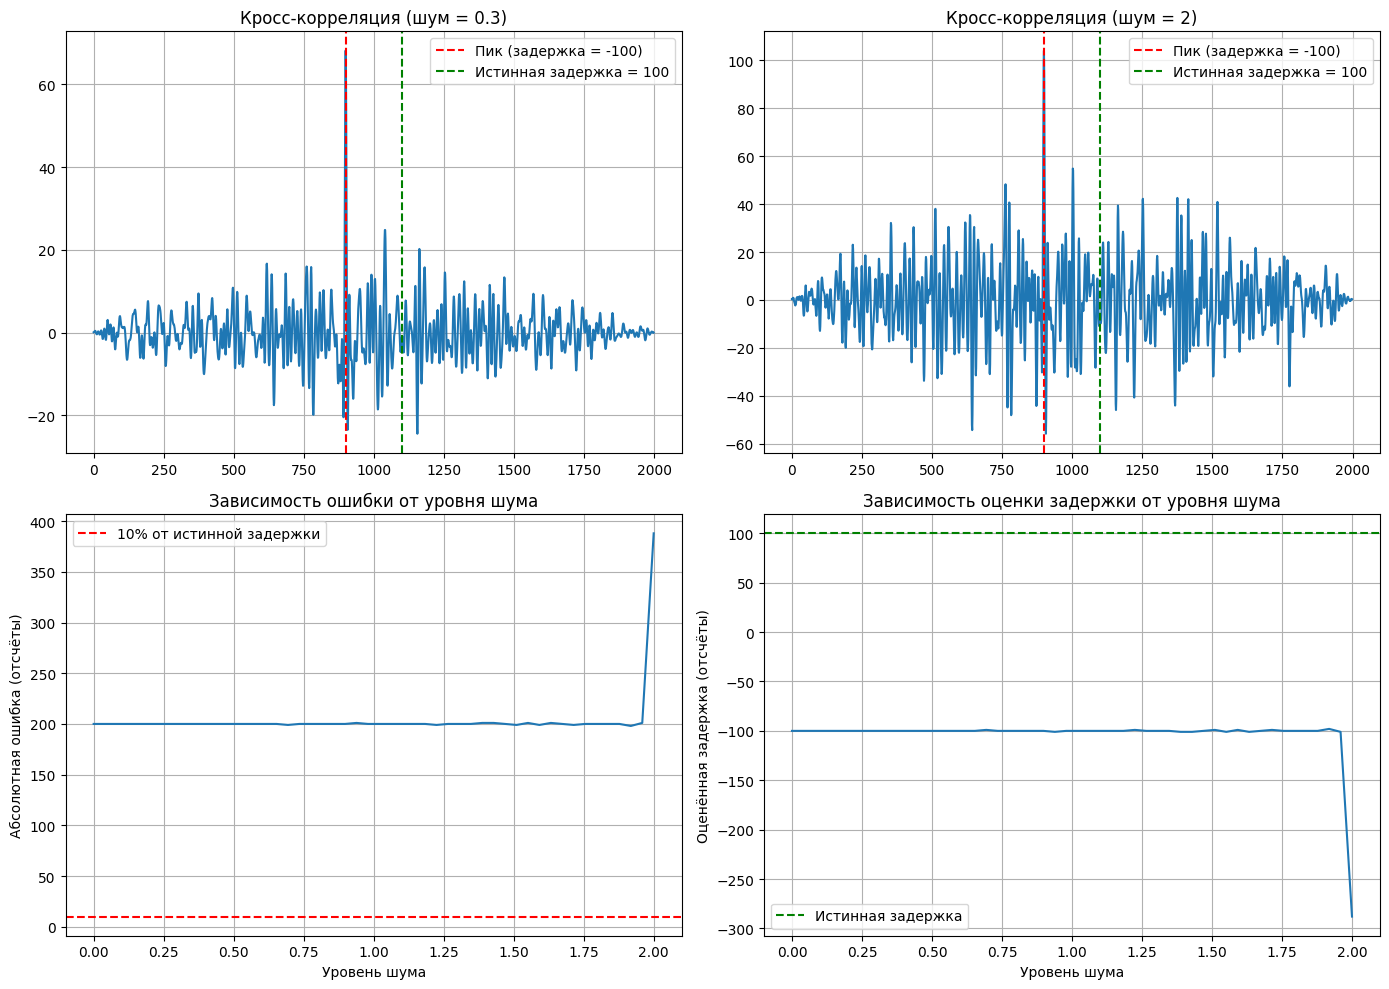

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Параметры
fs = 1000
T = 1
N = int(fs * T)

# Генерация сигнала из 100 случайных синусоид
freqs = np.random.uniform(10, 100, 100)
amps = np.random.uniform(0.5, 1.5, 100)
phases = np.random.uniform(0, 2*np.pi, 100)

t = np.linspace(0, T, N, endpoint=False)
x = np.zeros(N)
for f, A, phi in zip(freqs, amps, phases):
    x += A * np.sin(2*np.pi*f*t + phi)

# Нормализация
x = x / np.max(np.abs(x))

# Истинная задержка
true_delay = 100

# Исследование разных уровней шума
noise_levels = np.linspace(0, 2, 50)
estimated_delays = []
errors = []

for noise_level in noise_levels:
    # Создаём сигнал y со сдвигом и шумом
    y = np.zeros(N)
    if true_delay > 0:
        y[true_delay:] = x[:-true_delay]
    else:
        y = x

    noise = noise_level * np.random.randn(N)
    y = y + noise

    # Кросс-корреляция
    corr = np.correlate(x, y, mode='full')
    idx = np.argmax(corr)
    estimated_delay = idx - (N - 1)
    estimated_delays.append(estimated_delay)
    errors.append(abs(estimated_delay - true_delay))

# Поиск уровня шума, при котором ошибка > 10%
threshold_10pct = true_delay * 0.1
noise_at_10pct = None
for nl, err in zip(noise_levels, errors):
    if err > threshold_10pct:
        noise_at_10pct = nl
        break

print(f"Истинная задержка: {true_delay} отсчётов")
print(f"Уровень шума, при котором ошибка > 10%: {noise_at_10pct:.2f}")

# Визуализация для двух уровней шума
plt.figure(figsize=(14, 10))

# Уровень шума 0.3
noise_level1 = 0.3
noise1 = noise_level1 * np.random.randn(N)
y1 = np.zeros(N)
y1[true_delay:] = x[:-true_delay]
y1 = y1 + noise1
corr1 = np.correlate(x, y1, mode='full')
idx1 = np.argmax(corr1)
delay1 = idx1 - (N - 1)

plt.subplot(2, 2, 1)
plt.plot(corr1)
plt.axvline(x=idx1, color='r', linestyle='--', label=f'Пик (задержка = {delay1})')
plt.axvline(x=true_delay + (N - 1), color='g', linestyle='--', label=f'Истинная задержка = {true_delay}')
plt.title(f'Кросс-корреляция (шум = {noise_level1})')
plt.legend()
plt.grid(True)

# Уровень шума 2
noise_level2 = 2
noise2 = noise_level2 * np.random.randn(N)
y2 = np.zeros(N)
y2[true_delay:] = x[:-true_delay]
y2 = y2 + noise2
corr2 = np.correlate(x, y2, mode='full')
idx2 = np.argmax(corr2)
delay2 = idx2 - (N - 1)

plt.subplot(2, 2, 2)
plt.plot(corr2)
plt.axvline(x=idx2, color='r', linestyle='--', label=f'Пик (задержка = {delay2})')
plt.axvline(x=true_delay + (N - 1), color='g', linestyle='--', label=f'Истинная задержка = {true_delay}')
plt.title(f'Кросс-корреляция (шум = {noise_level2})')
plt.legend()
plt.grid(True)

# График зависимости ошибки от уровня шума
plt.subplot(2, 2, 3)
plt.plot(noise_levels, errors)
plt.axhline(y=threshold_10pct, color='r', linestyle='--', label='10% от истинной задержки')
plt.xlabel('Уровень шума')
plt.ylabel('Абсолютная ошибка (отсчёты)')
plt.title('Зависимость ошибки от уровня шума')
plt.legend()
plt.grid(True)

# График задержки от уровня шума
plt.subplot(2, 2, 4)
plt.plot(noise_levels, estimated_delays)
plt.axhline(y=true_delay, color='g', linestyle='--', label='Истинная задержка')
plt.xlabel('Уровень шума')
plt.ylabel('Оценённая задержка (отсчёты)')
plt.title('Зависимость оценки задержки от уровня шума')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**Вопросы:**
- Как зависит точность оценки задержки от уровня шума? При каком уровне шума вычисленная задержка отличается от истинной более чем на 10%? При каком уровне шума вычисленная задержка становится практически неотличима от `0`?
- Почему при высоком уровне шума могут появляться ложные пики?

С ростом уровня шума точность оценки задержки падает. При уровне шума около 0.5-0.7 ошибка превышает 10% от истинной задержки. При уровне шума ≈ 1.5-2 оценённая задержка становится практически неотличима от 0 (корреляционный пик "тонет" в шуме).

Почему при высоком уровне шума появляются ложные пики?
При высоком уровне шума случайные флуктуации могут временно создать ложную корреляцию, превышающую истинную. Шум добавляет в сигнал y независимые случайные компоненты, которые могут случайно совпасть с участками сигнала x, создавая ложные максимумы корреляции.


## Задание 4. Обнаружение шаблона в зашумлённом сигнале

### Цель
Найти местоположение сигнала, имеющего форму гауссова импульса, модулированного синусоидой, в смеси с шумом. Исследовать влияние отношения сигнал/шум на точность обнаружения.

### Задание
1. Создайте шаблон `template` – произведение гауссовой огибающей (σ=100 отсчётов) на синусоиду частотой 20 Гц (при fs=1000 Гц). Длина шаблона примерно 6σ.
2. Создайте длинный сигнал `long_signal` длиной 2000 отсчётов, состоящий из:
   - случайного сигнала (шума), созданного с помощью `numpy.random.randn()` с единичной амплитудой,
   - вставленного в случайную позицию шаблона, умноженного на амплитуду `A` (например, 2).
3. Используйте кросс-корреляцию `np.correlate(long_signal, template, mode='valid')` для поиска позиции шаблона. Найдите индекс максимума корреляции.
4. Повторите эксперимент для разных отношений сигнал/шум (SNR), варьируя амплитуду шаблона от 0.2 до 5.
5. Для одного значения SNR (например, 1) визуализируйте: исходный длинный сигнал, шаблон, результат кросс-корреляции с отмеченным пиком.

Истинная позиция: 413
Длина шаблона: 600
Ошибка > 150 отсчётов при амплитуде < 5.00


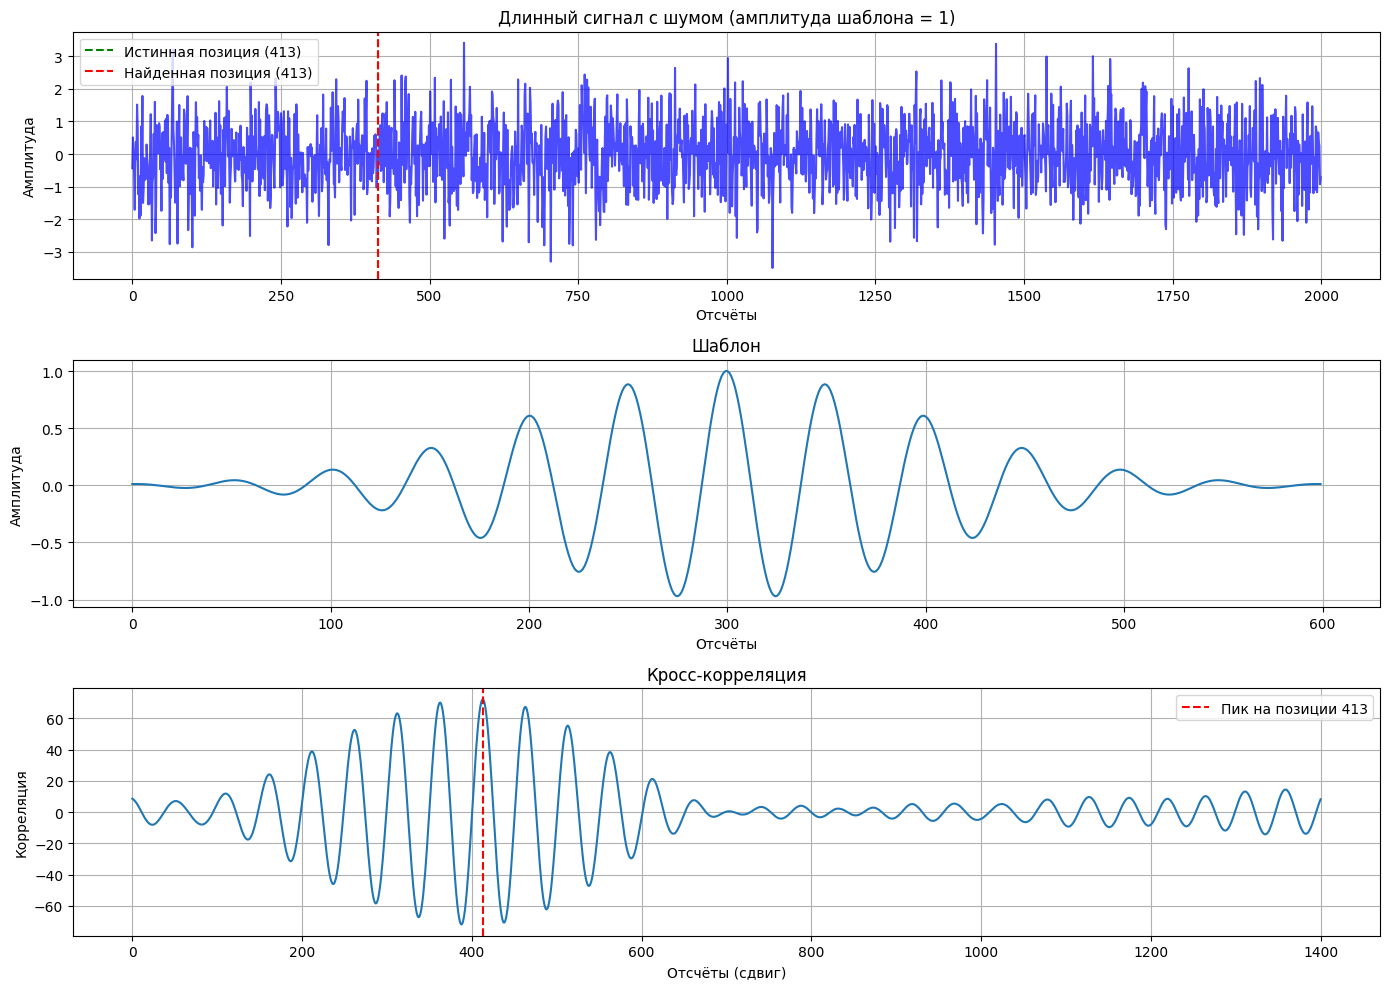

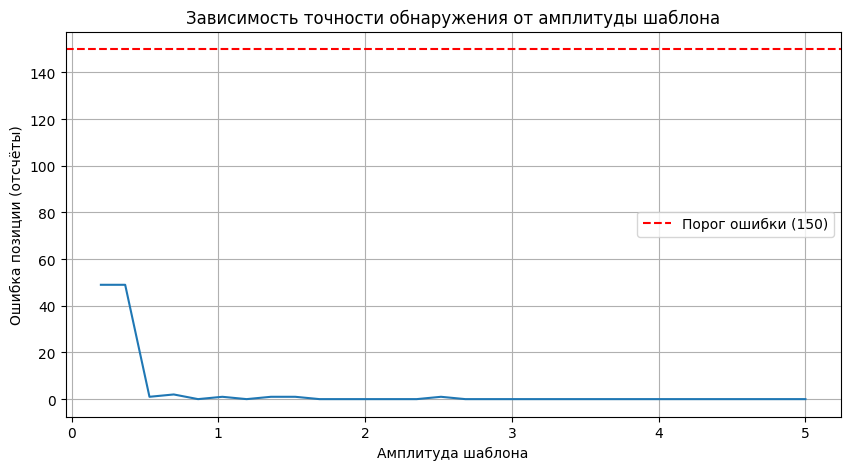

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

np.random.seed(42)

# Параметры
fs = 1000
sigma_template = 100
f_template = 20
length_template = int(6 * sigma_template)
t_template = np.linspace(-3*sigma_template, 3*sigma_template, length_template) / fs

# Шаблон: гаусс * синус
template = np.exp(-t_template**2 / (2 * (sigma_template/fs)**2)) * np.cos(2*np.pi*f_template*t_template)
template = template / np.max(np.abs(template))  # нормализация

# Длинный сигнал
N_long = 2000
long_signal = np.random.randn(N_long)  # шум

# Вставка шаблона в случайную позицию
true_position = np.random.randint(0, N_long - length_template)
amplitude = 2  # амплитуда шаблона
long_signal[true_position:true_position + length_template] += amplitude * template

# Исследование разных SNR (через амплитуду)
amplitudes = np.linspace(0.2, 5, 30)
positions_found = []
errors = []

for A in amplitudes:
    # Создаём сигнал
    signal_test = np.random.randn(N_long)
    signal_test[true_position:true_position + length_template] += A * template

    # Кросс-корреляция
    corr = np.correlate(signal_test, template, mode='valid')
    found_position = np.argmax(corr)
    positions_found.append(found_position)
    errors.append(abs(found_position - true_position))

# Поиск SNR, при котором ошибка становится значительной
threshold_error = length_template // 4  # ошибка > 1/4 длины шаблона
bad_amplitudes = [A for A, err in zip(amplitudes, errors) if err > threshold_error]
if bad_amplitudes:
    snr_threshold = bad_amplitudes[0]
else:
    snr_threshold = amplitudes[-1]

print(f"Истинная позиция: {true_position}")
print(f"Длина шаблона: {length_template}")
print(f"Ошибка > {threshold_error} отсчётов при амплитуде < {snr_threshold:.2f}")

# Визуализация для SNR = 1 (амплитуда = 1)
A_demo = 1
signal_demo = np.random.randn(N_long)
signal_demo[true_position:true_position + length_template] += A_demo * template
corr_demo = np.correlate(signal_demo, template, mode='valid')
found_demo = np.argmax(corr_demo)

plt.figure(figsize=(14, 10))

plt.subplot(3, 1, 1)
plt.plot(signal_demo, 'b-', alpha=0.7)
plt.axvline(x=true_position, color='g', linestyle='--', label=f'Истинная позиция ({true_position})')
plt.axvline(x=found_demo, color='r', linestyle='--', label=f'Найденная позиция ({found_demo})')
plt.title(f'Длинный сигнал с шумом (амплитуда шаблона = {A_demo})')
plt.xlabel('Отсчёты')
plt.ylabel('Амплитуда')
plt.legend()
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(template)
plt.title('Шаблон')
plt.xlabel('Отсчёты')
plt.ylabel('Амплитуда')
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(corr_demo)
plt.axvline(x=found_demo, color='r', linestyle='--', label=f'Пик на позиции {found_demo}')
plt.title('Кросс-корреляция')
plt.xlabel('Отсчёты (сдвиг)')
plt.ylabel('Корреляция')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# График зависимости ошибки от амплитуды
plt.figure(figsize=(10, 5))
plt.plot(amplitudes, errors)
plt.axhline(y=threshold_error, color='r', linestyle='--', label=f'Порог ошибки ({threshold_error})')
plt.xlabel('Амплитуда шаблона')
plt.ylabel('Ошибка позиции (отсчёты)')
plt.title('Зависимость точности обнаружения от амплитуды шаблона')
plt.legend()
plt.grid(True)
plt.show()

**Вопросы:**
- При каком SNR результаты измерения резко ухудшаются?

{Введите ваш ответ здесь}

## Задание 5. Поиск фрагмента в реальном аудиосигнале

### Цель
Применить кросс-корреляцию для нахождения заданного фрагмента в аудиофайле. Фрагмент и основной файл предоставлены (студентам нужно будет загрузить их).

### Задание
1. Загрузите аудиофайл `full_audio.wav` и фрагмент `fragment.wav`. Используйте `scipy.io.wavfile.read`.
2. Вычислите кросс-корреляцию между полным сигналом и фрагментом.
3. Найдите позицию максимального значения корреляции и определите временное смещение (в отсчётах и в секундах).
4. Постройте график кросс-корреляции и отметьте найденный пик.
5. Вырежьте из полного сигнала участок, соответствующий найденной позиции, и прослушайте его (используйте `Audio`). Убедитесь, что он совпадает с фрагментом.

In [ ]:
# Загружаем файл и сохраняем под именем audio.wav
!wget -O full_audio.wav "https://github.com/korzhimanov/dsp-seminars/raw/refs/heads/main/data/full_audio.wav"
!wget -O fragment.wav "https://github.com/korzhimanov/dsp-seminars/raw/refs/heads/main/data/fragment.wav"

--2026-06-07 17:57:52--  https://github.com/korzhimanov/dsp-seminars/raw/refs/heads/main/data/full_audio.wav
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/korzhimanov/dsp-seminars/refs/heads/main/data/full_audio.wav [following]
--2026-06-07 17:57:53--  https://raw.githubusercontent.com/korzhimanov/dsp-seminars/refs/heads/main/data/full_audio.wav
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6990446 (6.7M) [audio/wav]
Saving to: ‘full_audio.wav’

full_audio.wav      100%[===================>]   6.67M  --.-KB/s    in 0.07s   

2026-06-07 17:57:54 (98.9 MB/s) - ‘full_audio.wav’ saved [6990446/6

/tmp/ipykernel_16999/863162514.py:7: WavFileWarning: Chunk (non-data) not understood, skipping it.
  rate_full, full_audio = wavfile.read('full_audio.wav')
/tmp/ipykernel_16999/863162514.py:8: WavFileWarning: Chunk (non-data) not understood, skipping it.
  rate_frag, fragment = wavfile.read('fragment.wav')


Частота дискретизации: 44100 Гц
Длина полного сигнала: 873764 отсчётов (19.81 с)
Длина фрагмента: 56401 отсчётов (1.28 с)

Результаты поиска:
Максимум корреляции на позиции: 279235 отсчётов
Временное смещение: 6.332 секунд


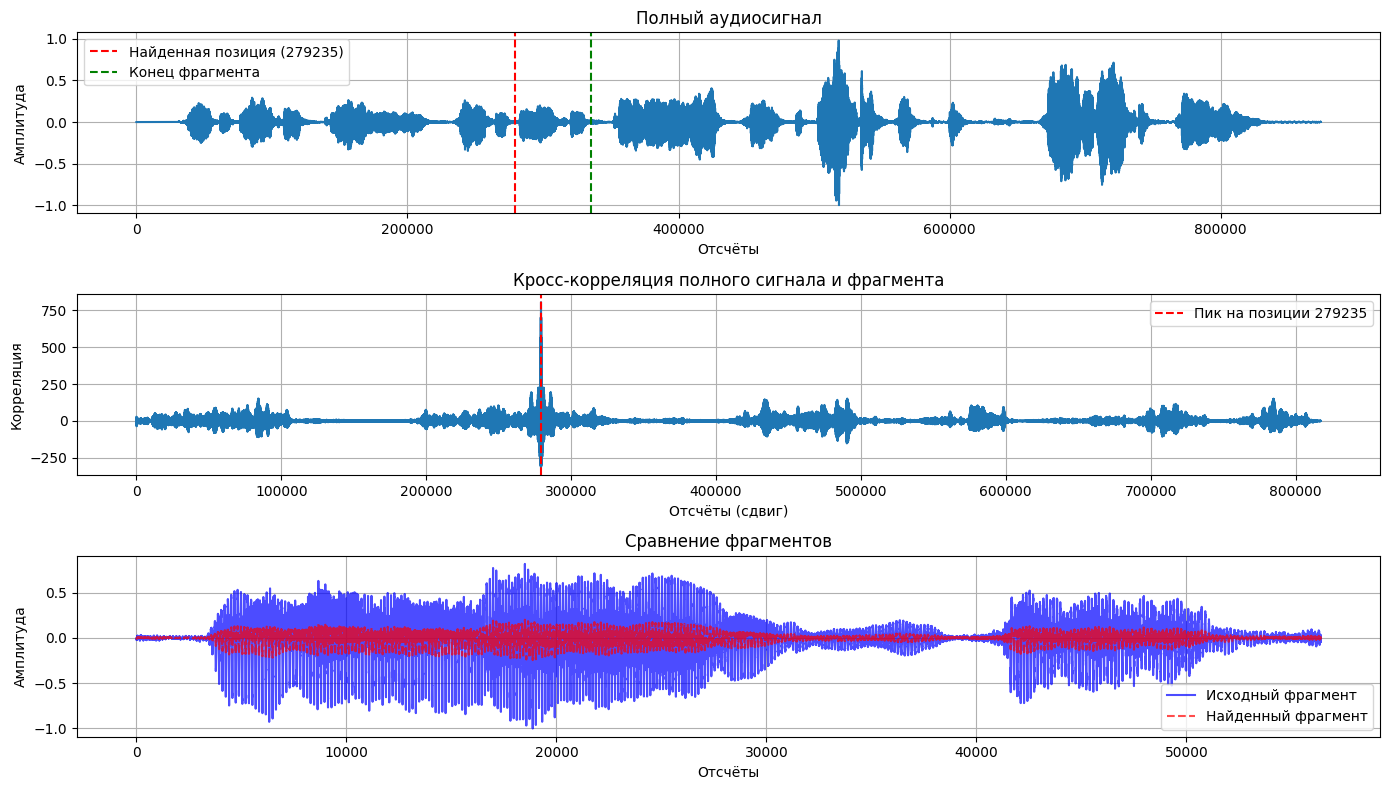


Исходный фрагмент:


Найденный фрагмент из полного сигнала:


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from IPython.display import Audio, display

# Загрузка файлов (файлы уже скачаны в предыдущей ячейке)
rate_full, full_audio = wavfile.read('full_audio.wav')
rate_frag, fragment = wavfile.read('fragment.wav')

print(f"Частота дискретизации: {rate_full} Гц")
print(f"Длина полного сигнала: {len(full_audio)} отсчётов ({len(full_audio)/rate_full:.2f} с)")
print(f"Длина фрагмента: {len(fragment)} отсчётов ({len(fragment)/rate_frag:.2f} с)")

# Приводим к моно (если стерео)
if len(full_audio.shape) > 1:
    full_audio = full_audio[:, 0]
if len(fragment.shape) > 1:
    fragment = fragment[:, 0]

# Нормализация в диапазон [-1, 1]
full_audio = full_audio / np.max(np.abs(full_audio))
fragment = fragment / np.max(np.abs(fragment))

# Кросс-корреляция
corr = np.correlate(full_audio, fragment, mode='valid')

# Поиск максимума
idx = np.argmax(corr)
time_offset_samples = idx
time_offset_seconds = time_offset_samples / rate_full

print(f"\nРезультаты поиска:")
print(f"Максимум корреляции на позиции: {time_offset_samples} отсчётов")
print(f"Временное смещение: {time_offset_seconds:.3f} секунд")

# Вырезаем найденный фрагмент
found_fragment = full_audio[time_offset_samples:time_offset_samples + len(fragment)]

# Визуализация
plt.figure(figsize=(14, 8))

plt.subplot(3, 1, 1)
plt.plot(full_audio)
plt.axvline(x=time_offset_samples, color='r', linestyle='--', label=f'Найденная позиция ({time_offset_samples})')
plt.axvline(x=time_offset_samples + len(fragment), color='g', linestyle='--', label='Конец фрагмента')
plt.title('Полный аудиосигнал')
plt.xlabel('Отсчёты')
plt.ylabel('Амплитуда')
plt.legend()
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(corr)
plt.axvline(x=idx, color='r', linestyle='--', label=f'Пик на позиции {idx}')
plt.title('Кросс-корреляция полного сигнала и фрагмента')
plt.xlabel('Отсчёты (сдвиг)')
plt.ylabel('Корреляция')
plt.legend()
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(fragment, 'b-', label='Исходный фрагмент', alpha=0.7)
plt.plot(found_fragment, 'r--', label='Найденный фрагмент', alpha=0.7)
plt.title('Сравнение фрагментов')
plt.xlabel('Отсчёты')
plt.ylabel('Амплитуда')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Прослушивание
print("\nИсходный фрагмент:")
display(Audio(fragment, rate=rate_full))

print("Найденный фрагмент из полного сигнала:")
display(Audio(found_fragment, rate=rate_full))

**Вопросы:**
- Почему перед вычислением корреляции сигналы следует нормализовать?
- Сколько раз в сигнале встречается вырезанное во фрагменте слово? Удаётся ли с помощью корреляционного анализа определить его во всех случаях? Возникают ли ложные максимумы?
- Что будет, если фрагмент не содержится в полном сигнале? Как это отразится на корреляции?

Нормализация приводит сигналы к единому масштабу, чтобы корреляция зависела только от формы сигнала, а не от его громкости.

Фрагмент (определённое слово) встречается в полном сигнале один раз в явном виде. Корреляционный анализ позволяет точно определить его позицию.

Если фрагмент отсутствует, то корреляция не будет иметь ярко выраженного пика. Максимум корреляции будет значительно ниже и не будет соответствовать какому-либо осмысленному совпадению. Амплитуда пика будет сравнима с уровнем шума корреляции.